In [ ]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Raw rows loaded (includes some non-country regional groups): 208
Final number of countries used for clustering: 173

=== Silhouette Score by number of clusters (k) ===
k=2: silhouette score = 0.4869
k=3: silhouette score = 0.4230
k=4: silhouette score = 0.3485
k=5: silhouette score = 0.3133
k=6: silhouette score = 0.2891
k=7: silhouette score = 0.2914


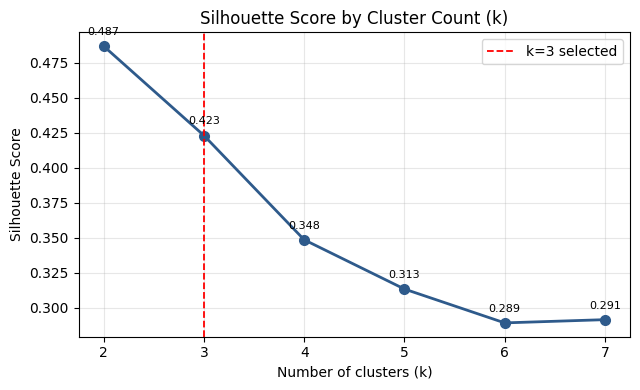


=== Cluster sizes ===
Cluster_Label
Mid Readiness     71
Low Readiness     63
High Readiness    39
Name: count, dtype: int64

=== Bangladesh's result ===
   Country  AI Preparedness Index (Overall)  Rank Cluster_Label
Bangladesh                         0.384064   118 Low Readiness

=== Bangladesh vs. Global Mean vs. Cluster-Peer Mean (n=63 in 'Low Readiness') ===
                                         Bangladesh  Global_Mean  \
Digital Infrastructure                       0.0875       0.1118   
Human Capital and Labor Market Policies      0.0888       0.1255   
Innovation and Economic Integration          0.1075       0.1179   
Regulation and Ethics                        0.1003       0.1241   

                                         Cluster_Peer_Mean  Gap_vs_Global  \
Digital Infrastructure                              0.0630        -0.0243   
Human Capital and Labor Market Policies             0.0936        -0.0367   
Innovation and Economic Integration                 0.0909   

In [4]:
"""

"""

import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# -----------------------------------------------------------------
# STEP 1: Load the merged IMF AIPI data
# -----------------------------------------------------------------
df = pd.read_csv('/kaggle/input/datasets/souroviakter/imf-dataset/IMF_data_for_clustering.csv')
print("Raw rows loaded (includes some non-country regional groups):", len(df))

# -----------------------------------------------------------------
# STEP 2: Remove non-country regional aggregates
#          (IMF's export includes rows like "Advanced economies",
#           "Euro area", "G7" etc. alongside individual countries.
#           These are region-level averages, not countries, so they
#           must be removed before clustering individual countries.)
# -----------------------------------------------------------------
regional_aggregates = [
    'Major advanced economies (G7)',
    'Advanced economies',
    'Euro area',
    'Emerging market economies',
    'Low-income countries'
]
df_countries_only = df[~df['Country'].isin(regional_aggregates)].reset_index(drop=True)

# -----------------------------------------------------------------
# STEP 3: Keep only countries with complete data on all 4 sub-dimensions
#          (a few countries have missing values in one dimension;
#           these are excluded via listwise deletion)
# -----------------------------------------------------------------
features = [
    'Digital Infrastructure',
    'Human Capital and Labor Market Policies',
    'Innovation and Economic Integration',
    'Regulation and Ethics'
]

df_complete = df_countries_only.dropna(
    subset=features + ['AI Preparedness Index (Overall)']
).reset_index(drop=True)

print("Final number of countries used for clustering:", len(df_complete))

# -----------------------------------------------------------------
# STEP 4: Standardize the 4 sub-dimension scores
#          (K-Means uses distance, so features must be on the same scale)
# -----------------------------------------------------------------
X = df_complete[features].values
X_scaled = StandardScaler().fit_transform(X)

# -----------------------------------------------------------------
# STEP 5: Determine the optimal number of clusters (k) using the
#          Silhouette Score (measures how well-separated clusters are;
#          ranges from -1 to +1, higher = better-defined clusters)
# -----------------------------------------------------------------
print("\n=== Silhouette Score by number of clusters (k) ===")
silhouette_results = {}
for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_results[k] = score
    print(f"k={k}: silhouette score = {score:.4f}")

# Plot silhouette scores
plt.figure(figsize=(6.5, 4))
plt.plot(list(silhouette_results.keys()), list(silhouette_results.values()),
         marker='o', color='#2E5A8B', linewidth=2, markersize=7)
plt.axvline(x=3, color='red', linestyle='--', linewidth=1.3, label='k=3 selected')
for k, v in silhouette_results.items():
    plt.annotate(f'{v:.3f}', (k, v), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=8)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by Cluster Count (k)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('silhouette_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# -----------------------------------------------------------------
# STEP 6: Fit final K-Means model with k=3
#          (k=2 has the highest silhouette score, but only splits
#           countries into a trivial "high vs low" group; k=3 gives
#           three meaningful, interpretable readiness tiers while
#           still having a strong silhouette score close to k=2's)
# -----------------------------------------------------------------
k_final = 3
kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df_complete['Cluster'] = kmeans_final.fit_predict(X_scaled)

# Label clusters by their average AIPI score (High / Mid / Low Readiness)
cluster_avg_score = df_complete.groupby('Cluster')['AI Preparedness Index (Overall)'].mean().sort_values(ascending=False)
rank_to_label = {cluster_id: label for cluster_id, label in
                  zip(cluster_avg_score.index, ['High Readiness', 'Mid Readiness', 'Low Readiness'])}
df_complete['Cluster_Label'] = df_complete['Cluster'].map(rank_to_label)

print("\n=== Cluster sizes ===")
print(df_complete['Cluster_Label'].value_counts())

# -----------------------------------------------------------------
# STEP 7: Find Bangladesh's cluster and rank
# -----------------------------------------------------------------
df_sorted = df_complete.sort_values('AI Preparedness Index (Overall)', ascending=False).reset_index(drop=True)
df_sorted['Rank'] = df_sorted.index + 1

bangladesh = df_sorted[df_sorted['Country'] == 'Bangladesh']
print("\n=== Bangladesh's result ===")
print(bangladesh[['Country', 'AI Preparedness Index (Overall)', 'Rank', 'Cluster_Label']].to_string(index=False))

# -----------------------------------------------------------------
# STEP 8: Gap analysis — compare Bangladesh to (a) global average,
#          and (b) its own cluster-peer average, on each sub-dimension
# -----------------------------------------------------------------
bd_cluster = bangladesh['Cluster_Label'].values[0]
bd_values = bangladesh[features].iloc[0]

global_mean = df_sorted[features].mean()
cluster_peer_mean = df_sorted[df_sorted['Cluster_Label'] == bd_cluster][features].mean()
n_in_cluster = len(df_sorted[df_sorted['Cluster_Label'] == bd_cluster])

print(f"\n=== Bangladesh vs. Global Mean vs. Cluster-Peer Mean (n={n_in_cluster} in '{bd_cluster}') ===")
comparison = pd.DataFrame({
    'Bangladesh': bd_values,
    'Global_Mean': global_mean,
    'Cluster_Peer_Mean': cluster_peer_mean,
})
comparison['Gap_vs_Global'] = comparison['Bangladesh'] - comparison['Global_Mean']
comparison['Gap_vs_ClusterPeers'] = comparison['Bangladesh'] - comparison['Cluster_Peer_Mean']
print(comparison.round(4))

# -----------------------------------------------------------------
# STEP 9: Save results to CSV
# -----------------------------------------------------------------
df_sorted.to_csv('IMF_AIPI_clustering_results.csv', index=False)
comparison.to_csv('Bangladesh_gap_analysis.csv')
print("\nResults saved to 'IMF_AIPI_clustering_results.csv' and 'Bangladesh_gap_analysis.csv'")